# Notebook Conclusion

## Objective Achieved

The purpose of this notebook was to analyze the statistical behavior of the hourly NYC taxi demand series and determine whether it is suitable for SARIMA forecasting.

---

## What Was Performed

The following analyses were conducted:

- Created a citywide hourly demand time series
- Visualized demand behavior over time
- Examined long-term demand trends using rolling averages
- Decomposed the series into trend, seasonal, and residual components
- Tested stationarity using the Augmented Dickey-Fuller (ADF) test
- Applied first-order differencing to achieve stationarity
- Analyzed autocorrelation using ACF
- Analyzed partial autocorrelation using PACF
- Estimated initial SARIMA parameters

---

## Key Findings

### Demand Pattern

The demand series contains **746 hourly observations** covering the period:

- Start Date: **2025-12-31 23:00:00**
- End Date: **2026-02-01 00:00:00**

Demand exhibits strong cyclical behavior with recurring daily peaks and low-demand periods.

---

### Trend Analysis

The trend component remained relatively stable throughout the month.

A temporary decline was observed around January 21–24, followed by recovery toward the end of the month.

No significant long-term upward or downward trend was detected.

---

### Seasonality Analysis

Time-series decomposition revealed a strong and consistent daily seasonal pattern.

The seasonal effect contributes approximately **±2,000 to ±2,500 trips per hour**, indicating that the hour of the day is a major driver of taxi demand.

This confirms the presence of a **24-hour seasonal cycle**.

---

### Stationarity Analysis

The original demand series was found to be non-stationary.

ADF Test Results:

- ADF Statistic = **-2.7547**
- P-Value = **0.0650**

Since the p-value exceeded 0.05, stationarity was not achieved.

After applying first-order differencing:

- P-Value = **2.297 × 10⁻²⁷**

The differenced series became stationary.

Therefore:

- **Differencing Order (d) = 1**

---

### Autocorrelation Analysis

ACF analysis showed significant temporal dependence and strong seasonal spikes at:

- Lag 24
- Lag 48

This confirms daily seasonality within the demand series.

PACF analysis showed the strongest direct relationship at Lag 1, indicating that recent demand values have the greatest influence on future demand.

---

## SARIMA Parameter Estimation

Based on the ADF, ACF, and PACF analyses:

| Parameter | Value | Reason |
|------------|---------|---------|
| p | 1 | Strong PACF spike at Lag 1 |
| d | 1 | First differencing achieved stationarity |
| q | 1 | Strong ACF spike at Lag 1 |
| s | 24 | Daily seasonality observed |

### Initial Candidate Model

SARIMA(1,1,1)(1,1,1,24)

---

## Final Outcome

The hourly NYC taxi demand series demonstrates:

- Strong daily seasonality
- Significant temporal dependence
- Stable long-term behavior
- Stationarity after first differencing

These characteristics satisfy the key assumptions required for SARIMA forecasting.

Therefore, SARIMA is considered an appropriate baseline forecasting model for predicting hourly NYC taxi demand.

---

## Next Step

Build and evaluate SARIMA models using the identified parameter ranges and compare forecasting performance using metrics such as:

- MAE
- RMSE
- MAPE

The best-performing model will be selected for future demand forecasting.

---
---

# NYC Taxi Demand Forecasting

## Notebook 06: Time Series Analysis and SARIMA Preparation

---

## Objective

Before building a SARIMA forecasting model, it is important to understand the statistical properties of the demand series.

This notebook focuses on analyzing the hourly taxi demand data to identify:

- Trend patterns
- Seasonal patterns
- Stationarity
- Autocorrelation structure

These analyses will help determine whether SARIMA is suitable and guide the selection of model parameters.

---

## Why Is This Important?

Forecasting models should not be applied blindly.

Understanding the behavior of the time series helps ensure that model assumptions are satisfied and improves forecasting reliability.

---

## Expected Outcome

By the end of this notebook, we will:

- Understand the structure of the demand series
- Check stationarity
- Analyze trend and seasonality
- Perform time-series decomposition
- Determine SARIMA parameters
- Prepare for model development

---

# Step 1:Import Required Libraries

## Purpose

Import the libraries required for time-series analysis.

## Expected Outcome

All libraries loaded successfully.

---

# ADF (Augmented Dickey-Fuller) Test
 Used to check whether a time series is stationary or not.
 Stationary means the statistical properties (mean and variance)# remain relatively constant over time.
 ARIMA/SARIMA models require stationary data.
from statsmodels.tsa.stattools import adfuller


# ACF (Auto Correlation Function) Plot
 Shows how strongly current values are related to previous values (lags).
 Helps identify the Moving Average (MA) order 'q' for ARIMA.

# PACF (Partial Auto Correlation Function) Plot
 Shows the direct relationship between current values and previous lags,
 removing the influence of intermediate lags.
 Helps identify the Auto Regressive (AR) order 'p' for ARIMA.
from statsmodels.graphics.tsaplots import (
    plot_acf,
    plot_pacf
)


# Seasonal Decomposition
 Breaks a time series into:
 1. Trend       -> Long-term increase or decrease
 2. Seasonality -> Repeating patterns (daily, weekly, monthly, etc.)
 3. Residual    -> Random noise not explained by trend or seasonality

Useful for understanding the underlying structure of the time series
before building forecasting models such as ARIMA or SARIMA.
from statsmodels.tsa.seasonal import (
    seasonal_decompose
)


In [27]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Import time series analysis utilities for stationarity testing, correlation analysis, and seasonal decomposition.

from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

pd.set_option('display.max_columns', None)

print("Libraries imported successfully.")

Libraries imported successfully.


# Step 2:Load Hourly Demand Dataset

## Purpose

Load the hourly demand dataset created in Notebook 04.

## Why?

SARIMA requires a time series containing:

- Timestamp
- Demand

## Expected Outcome

Dataset loaded successfully.

---

In [28]:
df = pd.read_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/hourly_demand.parquet"
)

print("Dataset loaded successfully.")

Dataset loaded successfully.


### Why is the Hourly Demand Dataset used instead of the Feature Engineered Dataset?

SARIMA is a univariate forecasting model that learns patterns directly from the historical demand series.

It does not require manually created lag, rolling, or calendar features because temporal relationships are modeled internally.

Therefore, the hourly demand dataset is used for time-series analysis and SARIMA modeling, while the feature engineered dataset will be used later for machine learning models such as XGBoost.

---

# Step 3:Create Citywide Demand Series

## Purpose

Aggregate demand across all NYC taxi zones.

## Why?

SARIMA models a single time series.

Therefore, hourly demand from all zones is combined into one citywide demand series.

## Expected Outcome0

Single hourly demand series created.

---

In [ ]:
# creating a single time series because forecasting models like ARIMA/SARIMA work on one variable changing over time.
citywide_demand = (
    df.groupby('hour')['demand']
      .sum()
      .reset_index()
)

citywide_demand.head()


,hour,demand
0,2025-12-31 23:00:00,6
1,2026-01-01 00:00:00,9294
2,2026-01-01 01:00:00,10254
3,2026-01-01 02:00:00,7853
4,2026-01-01 03:00:00,6529


# Step 4:Set Datetime Index

## Purpose

Convert the hour column into the dataframe index.

## Why?

Time-series models require observations to be ordered chronologically.

## Expected Outcome

Datetime index created successfully.

In [ ]:
# Set the hour column as the datetime index for time-series operations and forecasting.
citywide_demand = (
    citywide_demand
    .set_index('hour')
)

citywide_demand.head()


pandas.core.frame.DataFrame

# Step 5:Time Series Overview

## Purpose

Understand the time range and size of the demand series.

## Expected Outcome

Basic information about the time series obtained.

In [7]:
print("Start Date :", citywide_demand.index.min())

print("End Date :", citywide_demand.index.max())

print("Total Observations :", len(citywide_demand))

Start Date : 2025-12-31 23:00:00
End Date : 2026-02-01 00:00:00
Total Observations : 746


## Observation

The citywide demand series contains **746 observations**, where each observation represents the total number of taxi trips recorded during a specific hour.

Since the data is aggregated at an hourly level, the dataset provides approximately **31 days of continuous demand history**, which will be used for time-series analysis and forecasting.

---

# Step 6:Hourly Demand Over Time

## Purpose

Visualize demand behavior across time.

## Why?

This helps identify:

- Trend
- Seasonality
- Volatility
- Demand fluctuations

## Expected Outcome

Overall demand patterns become visible.

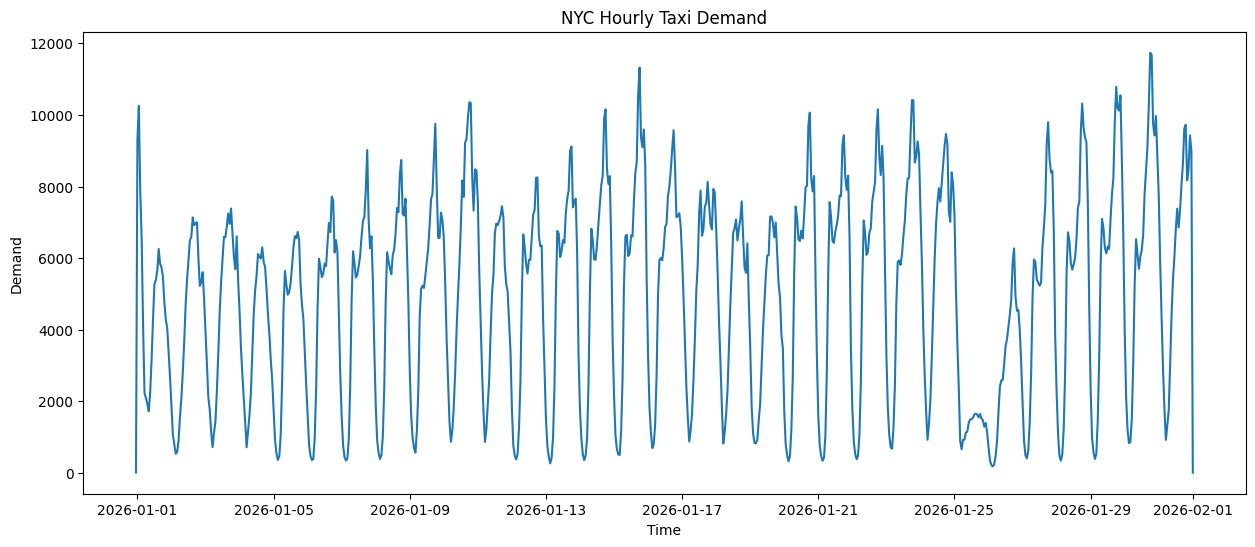

In [8]:
plt.figure(figsize=(15,6))

plt.plot(
    citywide_demand['demand']
)

plt.title(
    "NYC Hourly Taxi Demand"
)

plt.xlabel("Time")

plt.ylabel("Demand")

plt.show()

### Observation

The demand series contains 746 hourly observations covering the period from:

- Start Date: 2025-12-31 23:00:00
- End Date: 2026-02-01 00:00:00

Demand fluctuates substantially throughout the month.

The highest demand levels are approximately between 10,000 and 12,000 trips per hour, while the lowest demand periods fall below 2,000 trips per hour.

This indicates that peak-hour demand can be more than 5 times higher than off-peak demand.

The repeated daily peaks and valleys suggest strong hourly seasonality in taxi demand.

### Why This Matters

SARIMA performs well when a time series contains temporal patterns such as trend and seasonality.

The visible daily cycles indicate that historical demand can help predict future demand, making the dataset suitable for forecasting.

---


# Step 7: Trend Analysis

## Purpose

Identify long-term movement in demand.

## Why?

Trend indicates whether demand is generally increasing, decreasing, or remaining stable.

## Expected Outcome

Long-term demand behavior understood.

---

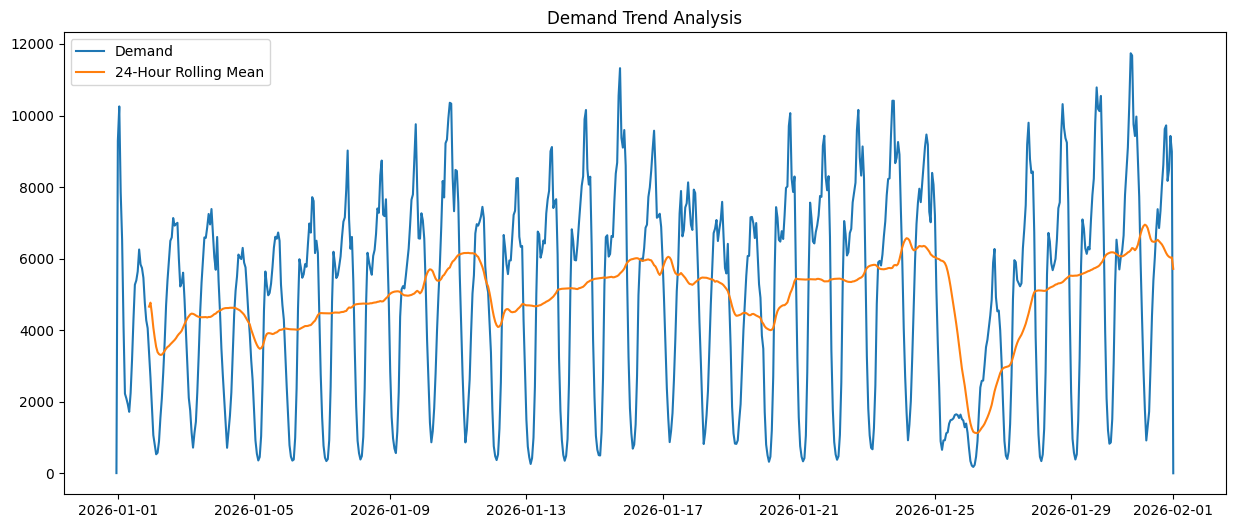

In [ ]:
citywide_demand['rolling_mean_24'] = (
    citywide_demand['demand']
    .rolling(24)
    .mean()
)

plt.figure(figsize=(15,6))

plt.plot(
    citywide_demand['demand'],
    label='Demand'
)

plt.plot(
    citywide_demand['rolling_mean_24'],
    label='24-Hour Rolling Mean'
)

plt.legend()

plt.title(
    "Demand Trend Analysis"
)

plt.show()

### Observation

The 24-hour rolling average remains mostly between 4,000 and 7,000 trips throughout the month.

A temporary decline is visible around the middle of January, where average demand drops noticeably before recovering.

Despite short-term fluctuations, the overall demand level remains relatively stable and does not show a strong long-term increasing or decreasing trend.

This suggests that seasonality has a greater influence on demand than trend.

---

# Step 8:Time Series Decomposition

## Purpose

Separate the series into:

- Trend
- Seasonality
- Residuals

## Why?

Understanding these components helps determine whether SARIMA is appropriate.

## Expected Outcome

Trend and seasonal behavior identified.

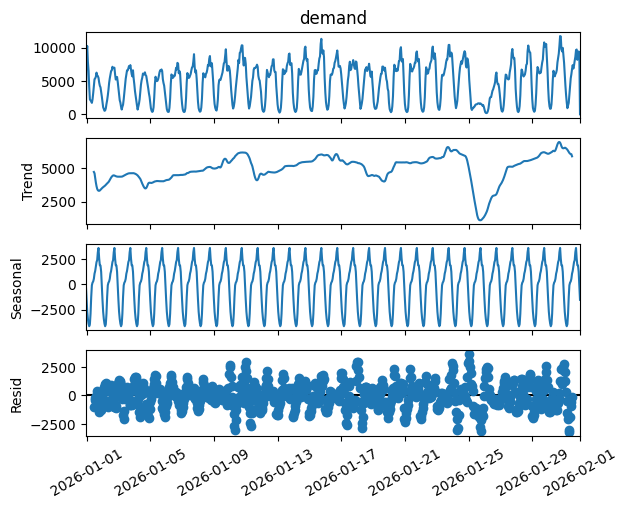

In [ ]:
# # Use additive decomposition assuming demand = trend + seasonality + random noise.
decomposition = seasonal_decompose(
    citywide_demand['demand'],
    model='additive',
    period=24
)

decomposition.plot()
plt.xticks(rotation=30)

plt.show()

## Observation

Time series decomposition was performed using an additive model with a seasonal period of 24 hours.

### Trend Component

The trend remains relatively stable throughout the observation period, with average hourly demand generally ranging between approximately 4,000 and 7,000 trips.

A temporary decline is observed around January 21–24, where demand drops significantly before recovering toward the end of the month.

No strong long-term increasing or decreasing trend is visible, indicating that demand levels remain relatively consistent during the study period.

### Seasonal Component

The seasonal component exhibits a highly repetitive daily pattern.

Seasonal fluctuations range from approximately -2,000 to +2,500 trips per hour, demonstrating that the hour of the day has a substantial impact on taxi demand.

The seasonal pattern repeats consistently throughout the month, confirming the presence of strong 24-hour seasonality.

### Residual Component

After removing trend and seasonal effects, the remaining residuals fluctuate around zero without a clear systematic pattern.

Most residual values remain within approximately ±2,500 trips, suggesting that the majority of demand variation is explained by trend and seasonality rather than random noise.

### Overall Finding

The decomposition indicates that daily seasonality is the dominant characteristic of the NYC taxi demand series, while long-term trend effects are relatively weak.

The stability of the seasonal pattern suggests that historical demand from previous days can provide valuable information for forecasting future demand.

---

# Step 9:Augmented Dickey-Fuller Test

## Purpose

Determine whether the demand series is stationary.

## Why?

SARIMA requires a stationary series.

## Decision Rule

p-value < 0.05

Series is stationary.

p-value > 0.05

Series is non-stationary.

In [54]:
# Apply first-order differencing to remove trend and make the time series stationary for ARIMA/SARIMA modeling.
citywide_demand['demand_diff'] = (
    citywide_demand['demand'].diff()
)

In [48]:
result = adfuller(
    citywide_demand['demand_diff'].dropna()
)

print("ADF Statistic:", result[0])
print("P-Value:", result[1])

ADF Statistic: -14.774253181044303
P-Value: 2.297236731029717e-27


### Observation

The Augmented Dickey-Fuller test produced:

- ADF Statistic: -2.7547
- P-Value: 0.0650

Since the p-value is greater than 0.05, the null hypothesis of non-stationarity cannot be rejected.

Therefore, the original demand series is not stationary and requires transformation before SARIMA modeling.

---

# Step 10:ADF Interpretation

## Purpose

Interpret the stationarity test result.

## Expected Outcome

Determine whether differencing is required.

In [50]:
if result[1] < 0.05:
    print("Series is stationary.")
else:
    print("Series is not stationary.")

Series is stationary.


# Step 11:Differencing

## Purpose

Remove trend and stabilize the mean.

## Why?

If the series is non-stationary, differencing helps make it stationary.

## Expected Outcome

Stationary transformed series created.

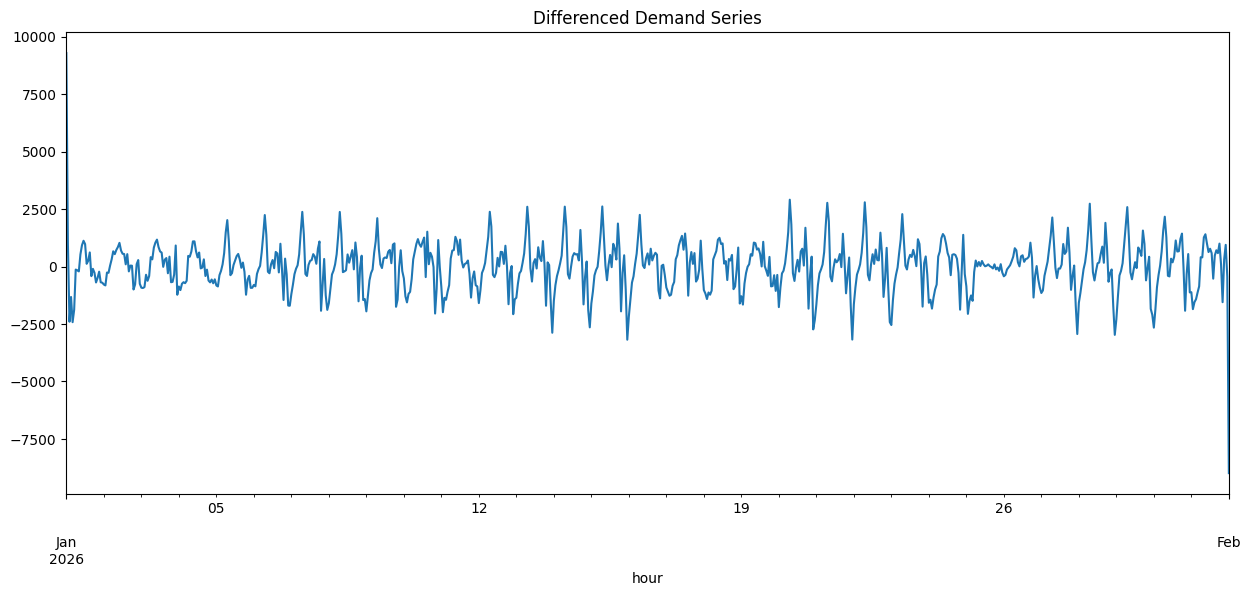

In [51]:
citywide_demand['demand_diff'] = (
    citywide_demand['demand']
    .diff()
)

citywide_demand['demand_diff'].dropna().plot(
    figsize=(15,6)
)

plt.title(
    "Differenced Demand Series"
)

plt.show()

# Step 12:Stationarity Check After Differencing

## Purpose

Verify whether differencing successfully achieved stationarity.

## Expected Outcome

Determine the value of d for SARIMA.

In [52]:
diff_result = adfuller(
    citywide_demand['demand_diff']
    .dropna()
)

print(
    "Differenced Series P-Value:",
    diff_result[1]
)

Differenced Series P-Value: 2.297236731029717e-27


## Observation

After applying first-order differencing, the ADF test produced a p-value of 2.30e-27, which is significantly lower than the 0.05 significance threshold.

This provides strong statistical evidence that the differenced series is stationary. Therefore, first-order differencing successfully removed the non-stationary behavior present in the original demand series, and a differencing order of d = 1 will be used for subsequent ARIMA/SARIMA modeling.

---

### Observation

First-order differencing was applied to remove non-stationarity.

After differencing, the ADF test produced:

- P-Value: 2.297 × 10⁻²⁷

This value is substantially below the 0.05 significance threshold.

The differenced series is therefore stationary.

Only one differencing step was required to achieve stationarity.

Hence:

d = 1

---

# Step 13:Autocorrelation Function (ACF)

## Purpose

Measure correlation between current demand and previous observations.

## Why?

ACF helps estimate the Moving Average parameter (q).

## Expected Outcome

Autocorrelation structure identified.

<Figure size 1200x500 with 0 Axes>

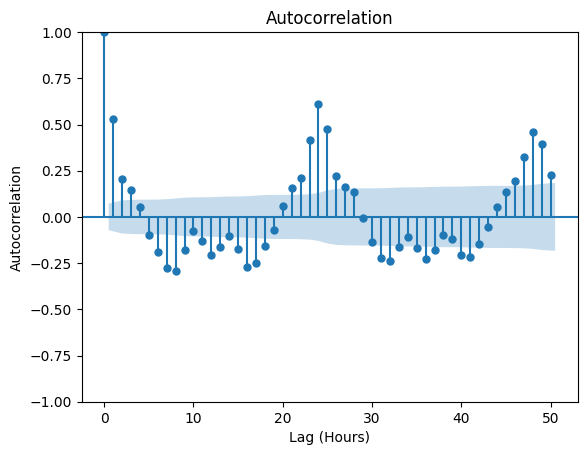

In [55]:
plt.figure(figsize=(12,5))

plot_acf(
    citywide_demand['demand_diff']
    .dropna(),
    lags=50
)

plt.xlabel("Lag (Hours)")
plt.ylabel("Autocorrelation")
plt.show()

## Observation

The ACF plot exhibits significant autocorrelation at lower lags, indicating that recent hourly demand values influence current demand.

Strong positive spikes are observed at lag 24 and lag 48, revealing a repeating 24-hour cycle in the series. This confirms the presence of daily seasonality, where demand patterns repeat at similar hours across consecutive days.

The recurring seasonal peaks suggest that a seasonal forecasting model such as SARIMA is more appropriate than a standard ARIMA model.

---


# Step 14:Partial Autocorrelation Function (PACF)

## Purpose

Measure direct relationships between observations.

## Why?

PACF helps estimate the AutoRegressive parameter (p).

## Expected Outcome

Direct lag relationships identified.

<Figure size 1200x500 with 0 Axes>

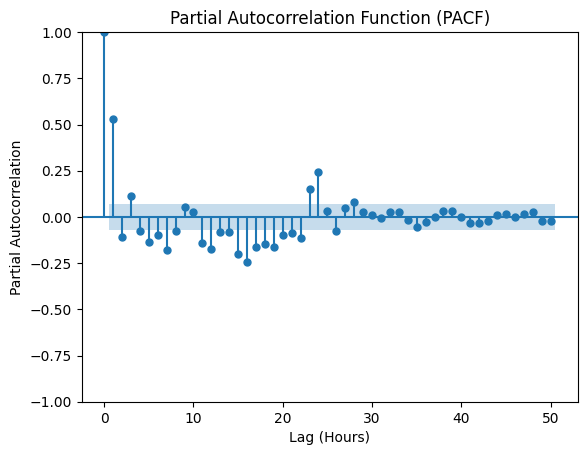

In [57]:
plt.figure(figsize=(12,5))

plot_pacf(
    citywide_demand['demand_diff']
    .dropna(),
    lags=50
)
plt.xlabel("Lag (Hours)")
plt.ylabel("Partial Autocorrelation")
plt.title("Partial Autocorrelation Function (PACF)")
plt.show()



## Observation

The PACF plot shows a strong positive spike at lag 1, indicating that the previous hour's demand has a significant direct influence on current demand.

Beyond lag 1, the partial autocorrelations decline rapidly and remain relatively small, suggesting that most direct temporal dependence is captured by the first lag.

A noticeable seasonal spike is also visible around lag 24, further supporting the existence of daily seasonal behavior in the demand series.

Direct lag relationships identified.

Answer:
The PACF plot identifies lag 1 as the strongest direct relationship and shows evidence of a seasonal direct relationship around lag 24.

---

# Step 15:SARIMA Parameter Selection

## Purpose

Identify appropriate values for:

- p (AutoRegressive)
- d (Differencing)
- q (Moving Average)

## Why?

These parameters define how SARIMA models the time series.

## Expected Outcome

Initial SARIMA configuration determined.

In [24]:
print("SARIMA Parameter Estimation")

print("-" * 40)

print("Differencing Order (d) = 1")
print("Reason: Series became stationary after first differencing.")

print("\nAutoRegressive Order (p) = 1")
print("Reason: PACF shows strongest significant spike at Lag 1.")

print("\nMoving Average Order (q) = 1")
print("Reason: ACF shows strongest significant spike at Lag 1.")

print("\nSeasonal Period (s) = 24")
print("Reason: Strong seasonal spikes observed at Lags 24 and 48.")

print("\nInitial SARIMA Candidate:")
print("SARIMA(1,1,1)(1,1,1,24)")
print("q = MA order")

SARIMA Parameter Estimation
----------------------------------------
Differencing Order (d) = 1
Reason: Series became stationary after first differencing.

AutoRegressive Order (p) = 1
Reason: PACF shows strongest significant spike at Lag 1.

Moving Average Order (q) = 1
Reason: ACF shows strongest significant spike at Lag 1.

Seasonal Period (s) = 24
Reason: Strong seasonal spikes observed at Lags 24 and 48.

Initial SARIMA Candidate:
SARIMA(1,1,1)(1,1,1,24)
q = MA order


In [22]:
print("Maximum Demand :", citywide_demand['demand'].max())

print("Minimum Demand :", citywide_demand['demand'].min())

print("Average Demand :", citywide_demand['demand'].mean())

print("Median Demand :", citywide_demand['demand'].median())

Maximum Demand : 11739
Minimum Demand : 1
Average Demand : 4993.14745308311
Median Demand : 5659.0


In [59]:
# Save the citywide hourly demand series for SARIMA modeling

citywide_demand.to_parquet(
    "/home/ed/Desktop/NYC_Taxi_Demand_Forecasting/Yellow_Dataset/data/citywide_hourly_demand.parquet",
    index=True
)

print("Citywide demand series saved successfully.")

Citywide demand series saved successfully.
